In [26]:
import pandas as pd

# Load full dataset
data_dir = "/Users/muberraozmen/Development/psycho-pass/experiments/dataset_feb3_1770230537/embeddings_base_1771228851/embeddings.parquet"
df = pd.read_parquet(data_dir)

# Filter out to objectives with at least one success and one failure
df["objective_category"] = df["objective"].astype("category").cat.codes
mixed_objectives = df.groupby("objective_category")[["is_success", "is_failure"]].sum()
mask = (mixed_objectives["is_success"] > 0) & (mixed_objectives["is_failure"] > 0)
mixed_objectives = mixed_objectives[mask].index.tolist()
df = df[df["objective_category"].isin(mixed_objectives)]


# Flatten the dataframe
df["sequence"] = df["turn_count"].apply(lambda x: list(range(x)))
df = df.explode(["sequence", "embeddings"])

# Clean up the dataframe
df = df[["conversation_id", "objective_category", "is_success", "sequence", "embeddings"]]
df.reset_index(drop=True, inplace=True)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE

# Calculate TSNE
embeddings = np.array(df["embeddings"].to_list())
tsne = TSNE(n_components=2, random_state=42).fit_transform(embeddings)
df['tsne_x'], df['tsne_y'] = tsne[:, 0], tsne[:, 1]

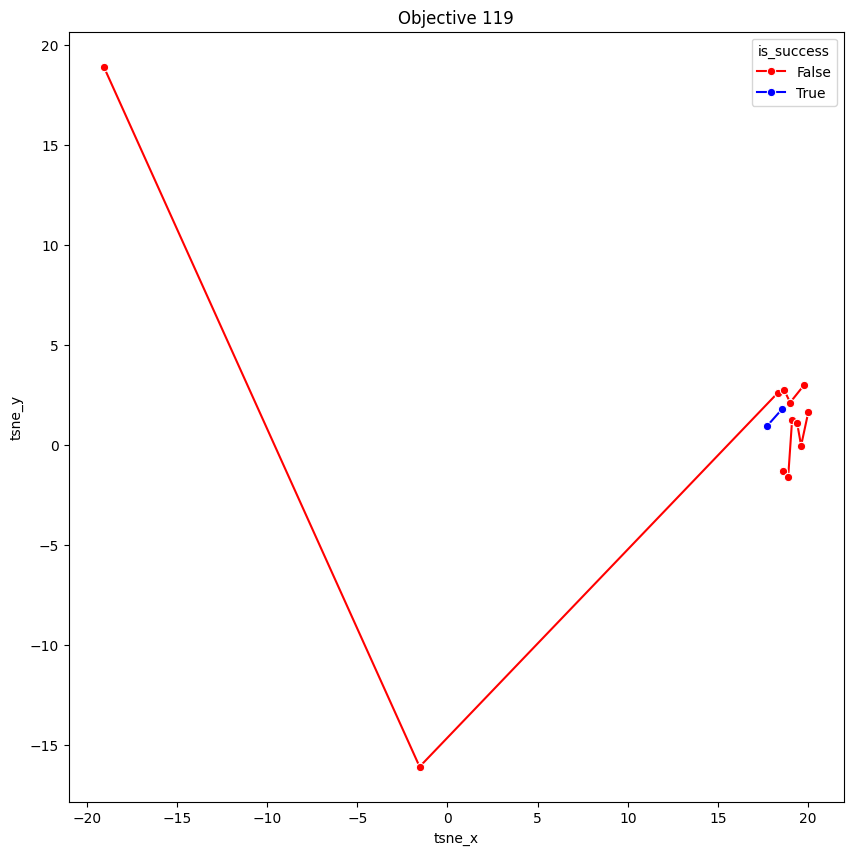

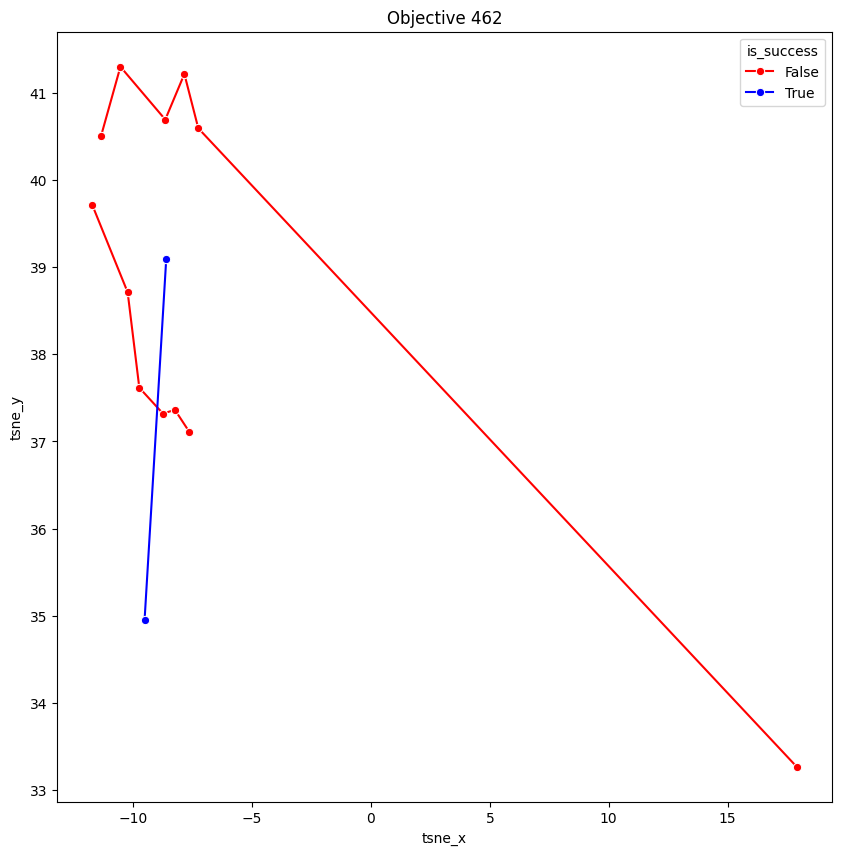

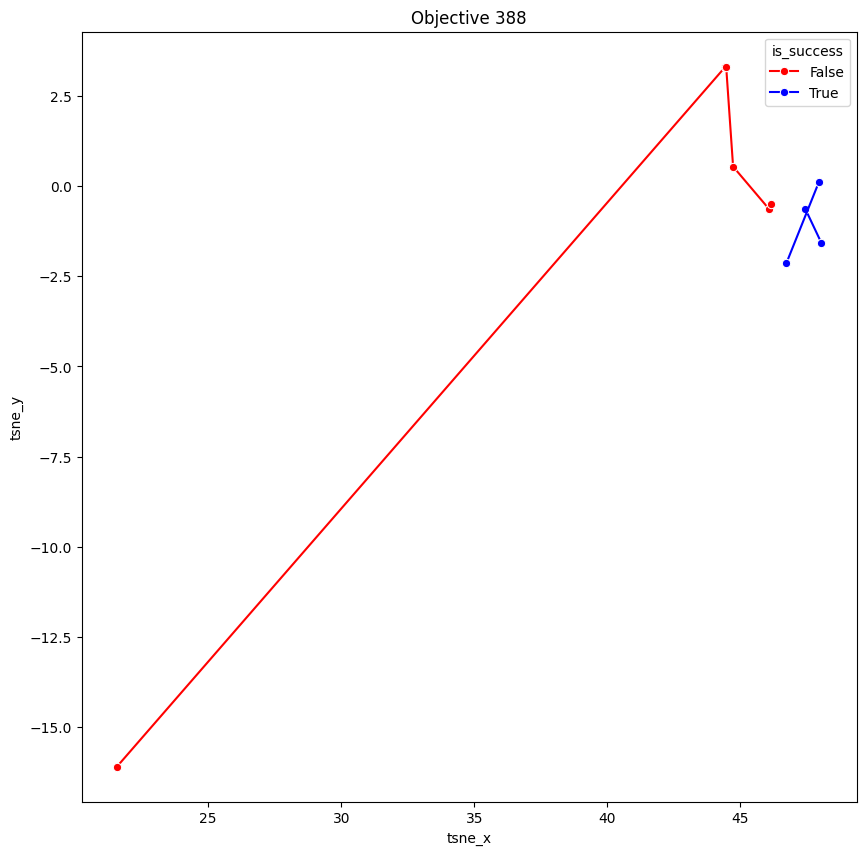

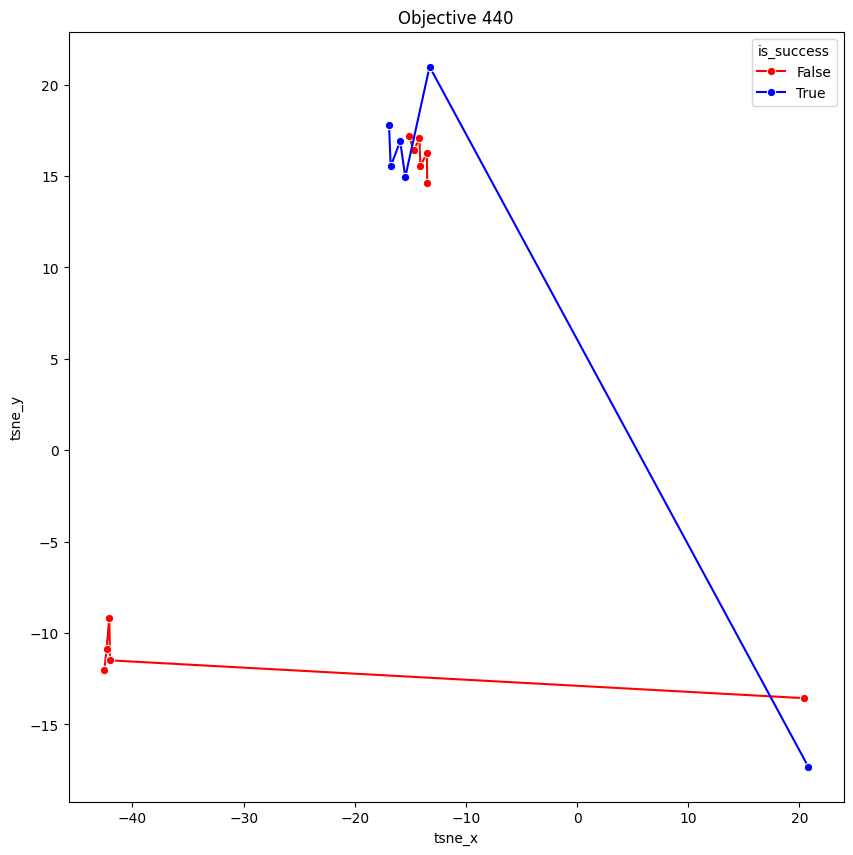

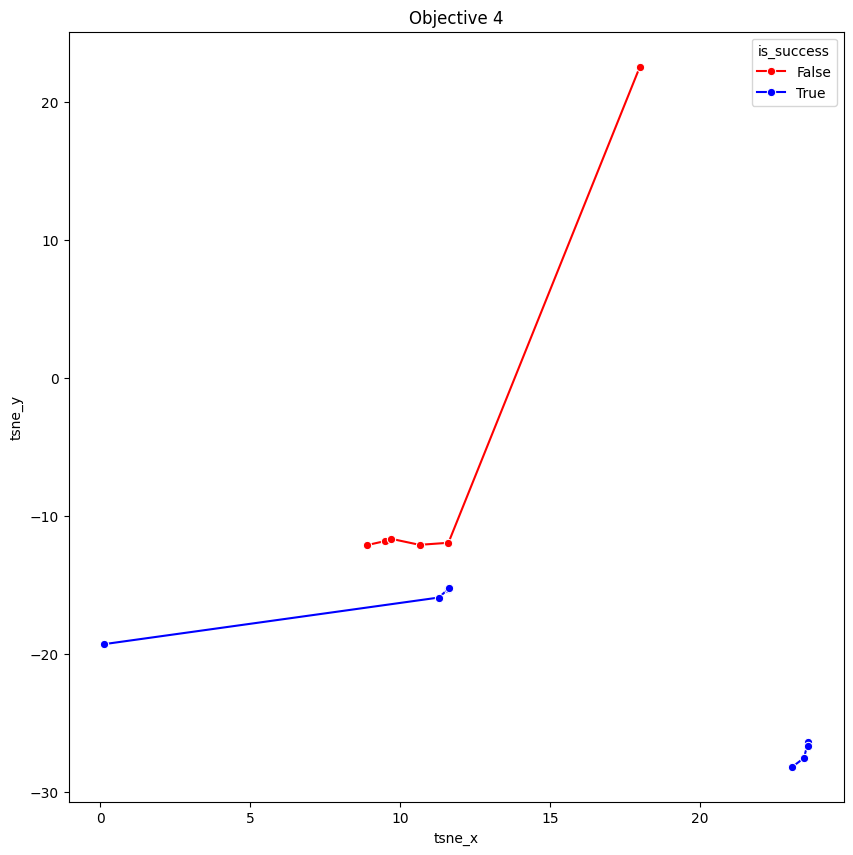

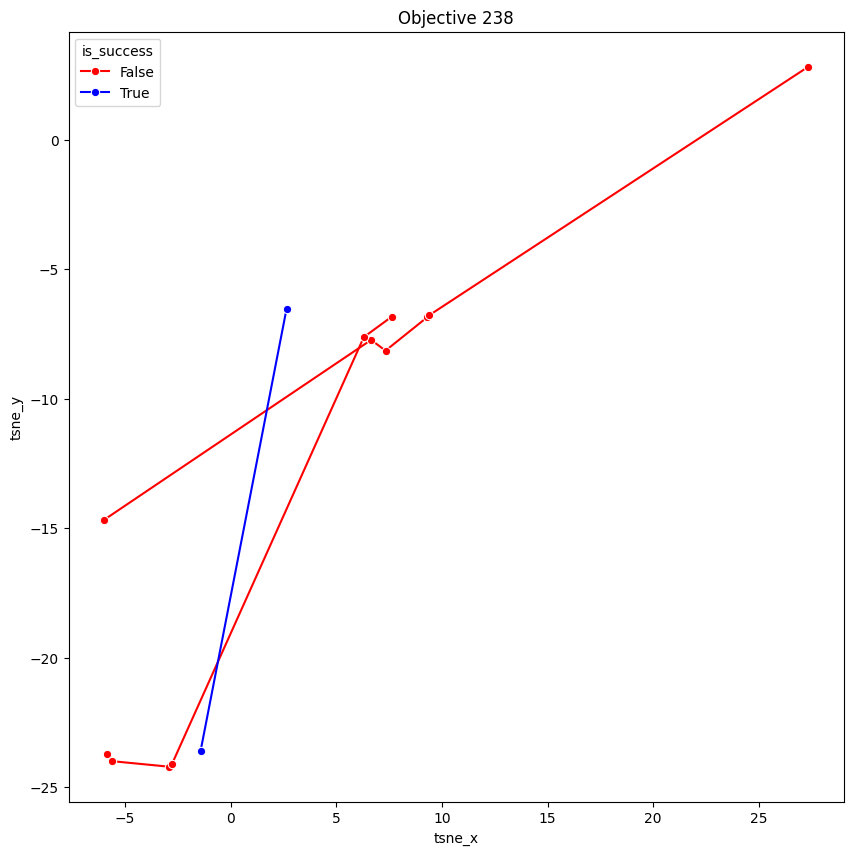

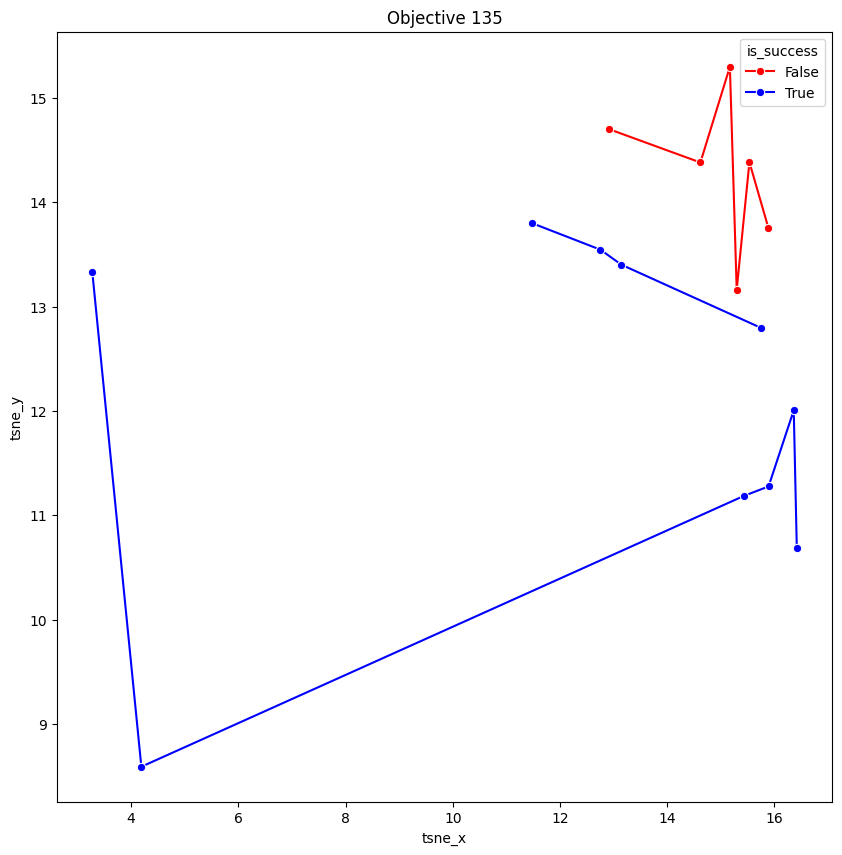

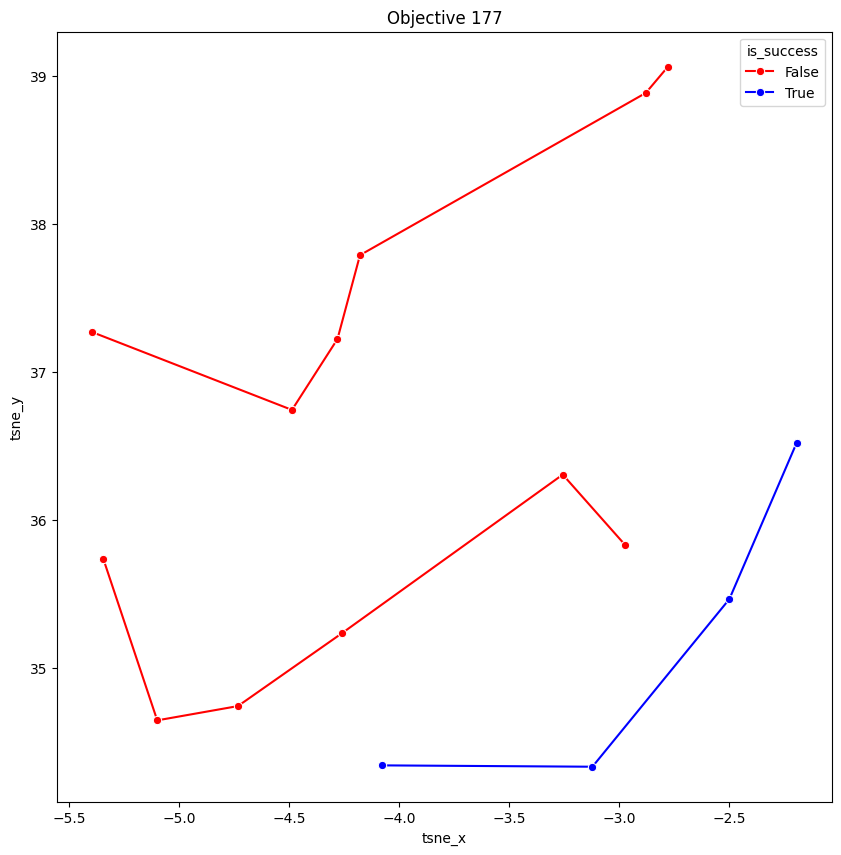

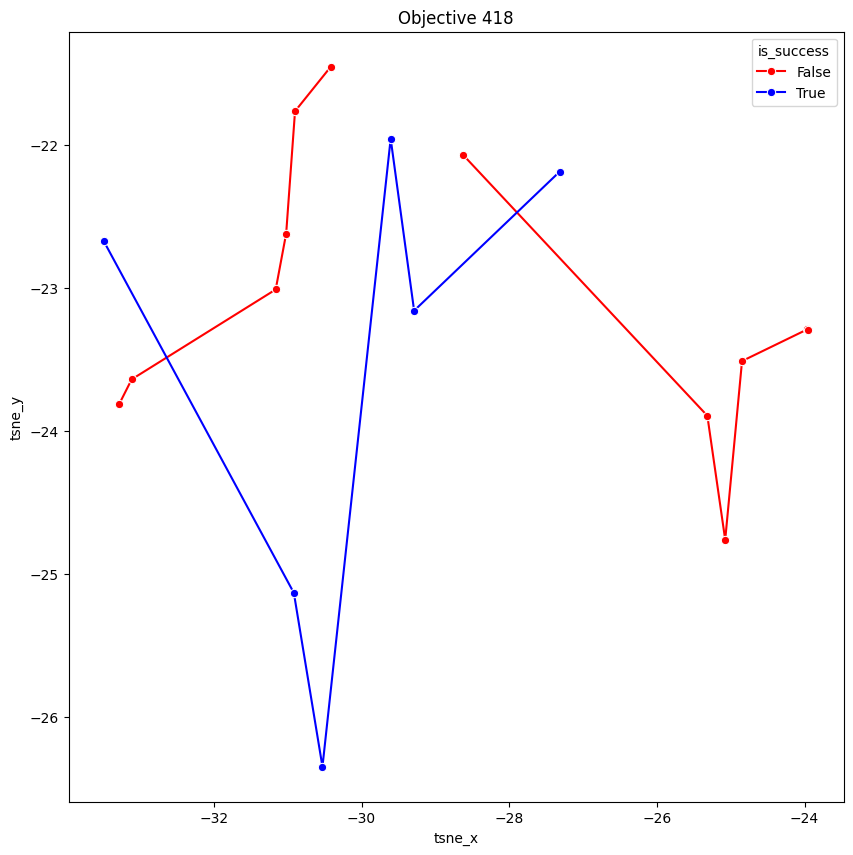

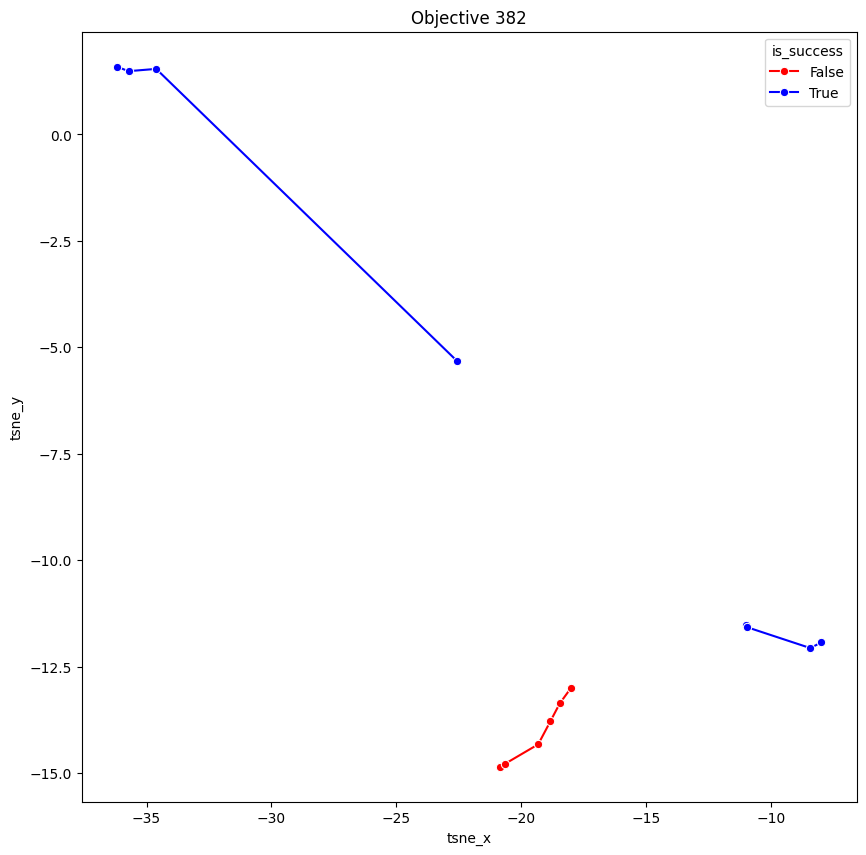

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

for obj in df["objective_category"].unique().tolist()[10:20]:
    
    df_obj = df[df["objective_category"] == obj].sort_values(by='sequence')
    plt.figure(figsize=(10, 10))
    sns.lineplot(
        data=df_obj,
        x='tsne_x',
        y='tsne_y',
        hue='is_success',
        units='conversation_id',
        marker='o',
        palette={False: 'red', True: 'blue'},
        legend=True
    ).set_title(f"Objective {obj}")
    plt.show()
